# sarimax Playground

Interactive environment to step through the `sarimax.py` pipeline for Retail Forecasting.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Point to project root
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.sarimax import (
    load_processed_data,
    preprocess_and_split,
    tune_hyperparameters, 
    train_models, 
    predict_models, 
    evaluate_models,
    save_artifacts
)
from src.tools import plot_cluster_portfolio, analyze_time_periods, plot_mape_vs_volume

## 1. Load Processed Data

In [2]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = load_processed_data(data_path)
df_long.head()

Loading processed data...


,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,volume_tier,semantic_cluster_name,ADI,CV2,demand_class,share_zero_weeks,price_median,mean_basket_size,n_unique_customers,country_uk_share
0,10133,2009-11-30,85,73.10,49,11,4,2009,-4.566292e-01,0.889657,...,Low,SET + BOX + PACK,1.260274,1.528233,erratic,0.206522,0.83,12.672414,151,0.958621
1,10133,2009-12-07,48,40.80,50,12,4,2009,-3.482016e-01,0.937420,...,Low,SET + BOX + PACK,1.260274,1.528233,erratic,0.206522,0.83,12.672414,151,0.958621
2,10133,2009-12-14,21,17.85,51,12,4,2009,-2.348860e-01,0.972023,...,Low,SET + BOX + PACK,1.260274,1.528233,erratic,0.206522,0.83,12.672414,151,0.958621
3,10133,2009-12-21,0,0.00,52,12,4,2009,-1.182732e-01,0.992981,...,Low,SET + BOX + PACK,1.260274,1.528233,erratic,0.206522,0.83,12.672414,151,0.958621
4,10133,2009-12-28,0,0.00,53,12,4,2009,-2.449294e-16,1.000000,...,Low,SET + BOX + PACK,1.260274,1.528233,erratic,0.206522,0.83,12.672414,151,0.958621


## 2. Preprocess & Split
Scales the continuous features (MinMaxScaler) per StockCode and drops unnecessary columns.

In [3]:
train_agg, test_agg, test_raw, regressors = preprocess_and_split(df_long)
print(f'Train shape: {train_agg.shape}')
print(f'Test shape: {train_agg.shape}')

Preparing train/test split and log-scaling for SARIMAX...
Applying log1p scaling to Quantity...
Aggregating data and regressors by Cluster for SARIMAX training...
Train shape: (460, 8)
Test shape: (460, 8)


## 3. Train Models per Seasonal Profile

In [4]:
best_params = tune_hyperparameters(train_agg, regressors, n_trials=50)
cluster_models = train_models(train_agg, regressors, params=best_params)


Optuna: Tuning SARIMAX (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best SARIMAX params (WMAPE=34.35%): {'p': 0, 'd': 2, 'q': 1, 'P': 1, 'D': 0, 'Q': 1}
Training SARIMAX models for 5 clusters...


Training: 100%|██████████| 5/5 [00:04<00:00,  1.09it/s]


## 4. Predict on Test Set

In [5]:
test_raw = predict_models(cluster_models, test_agg, test_raw, regressors)

Generating forecasts and un-scaling to raw Quantity...
Inverse transforming predictions (expm1)...


## 5. Evaluate

In [6]:
cluster_eval, summary = evaluate_models(test_raw)
summary


Evaluating Portfolio Performance...


,WMAPE,Median_MAPE,Mean_Absolute_Error
Cluster,,,
Global,90.28,79.61,65.49
0,94.72,80.43,27.26
1,91.88,80.30,99.81
2,93.25,79.56,36.73
3,91.66,86.91,19.67
4,87.98,78.12,77.77


## 6. Visualization

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats = c_data.groupby("StockCode", observed=True).apply(
/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_stats 

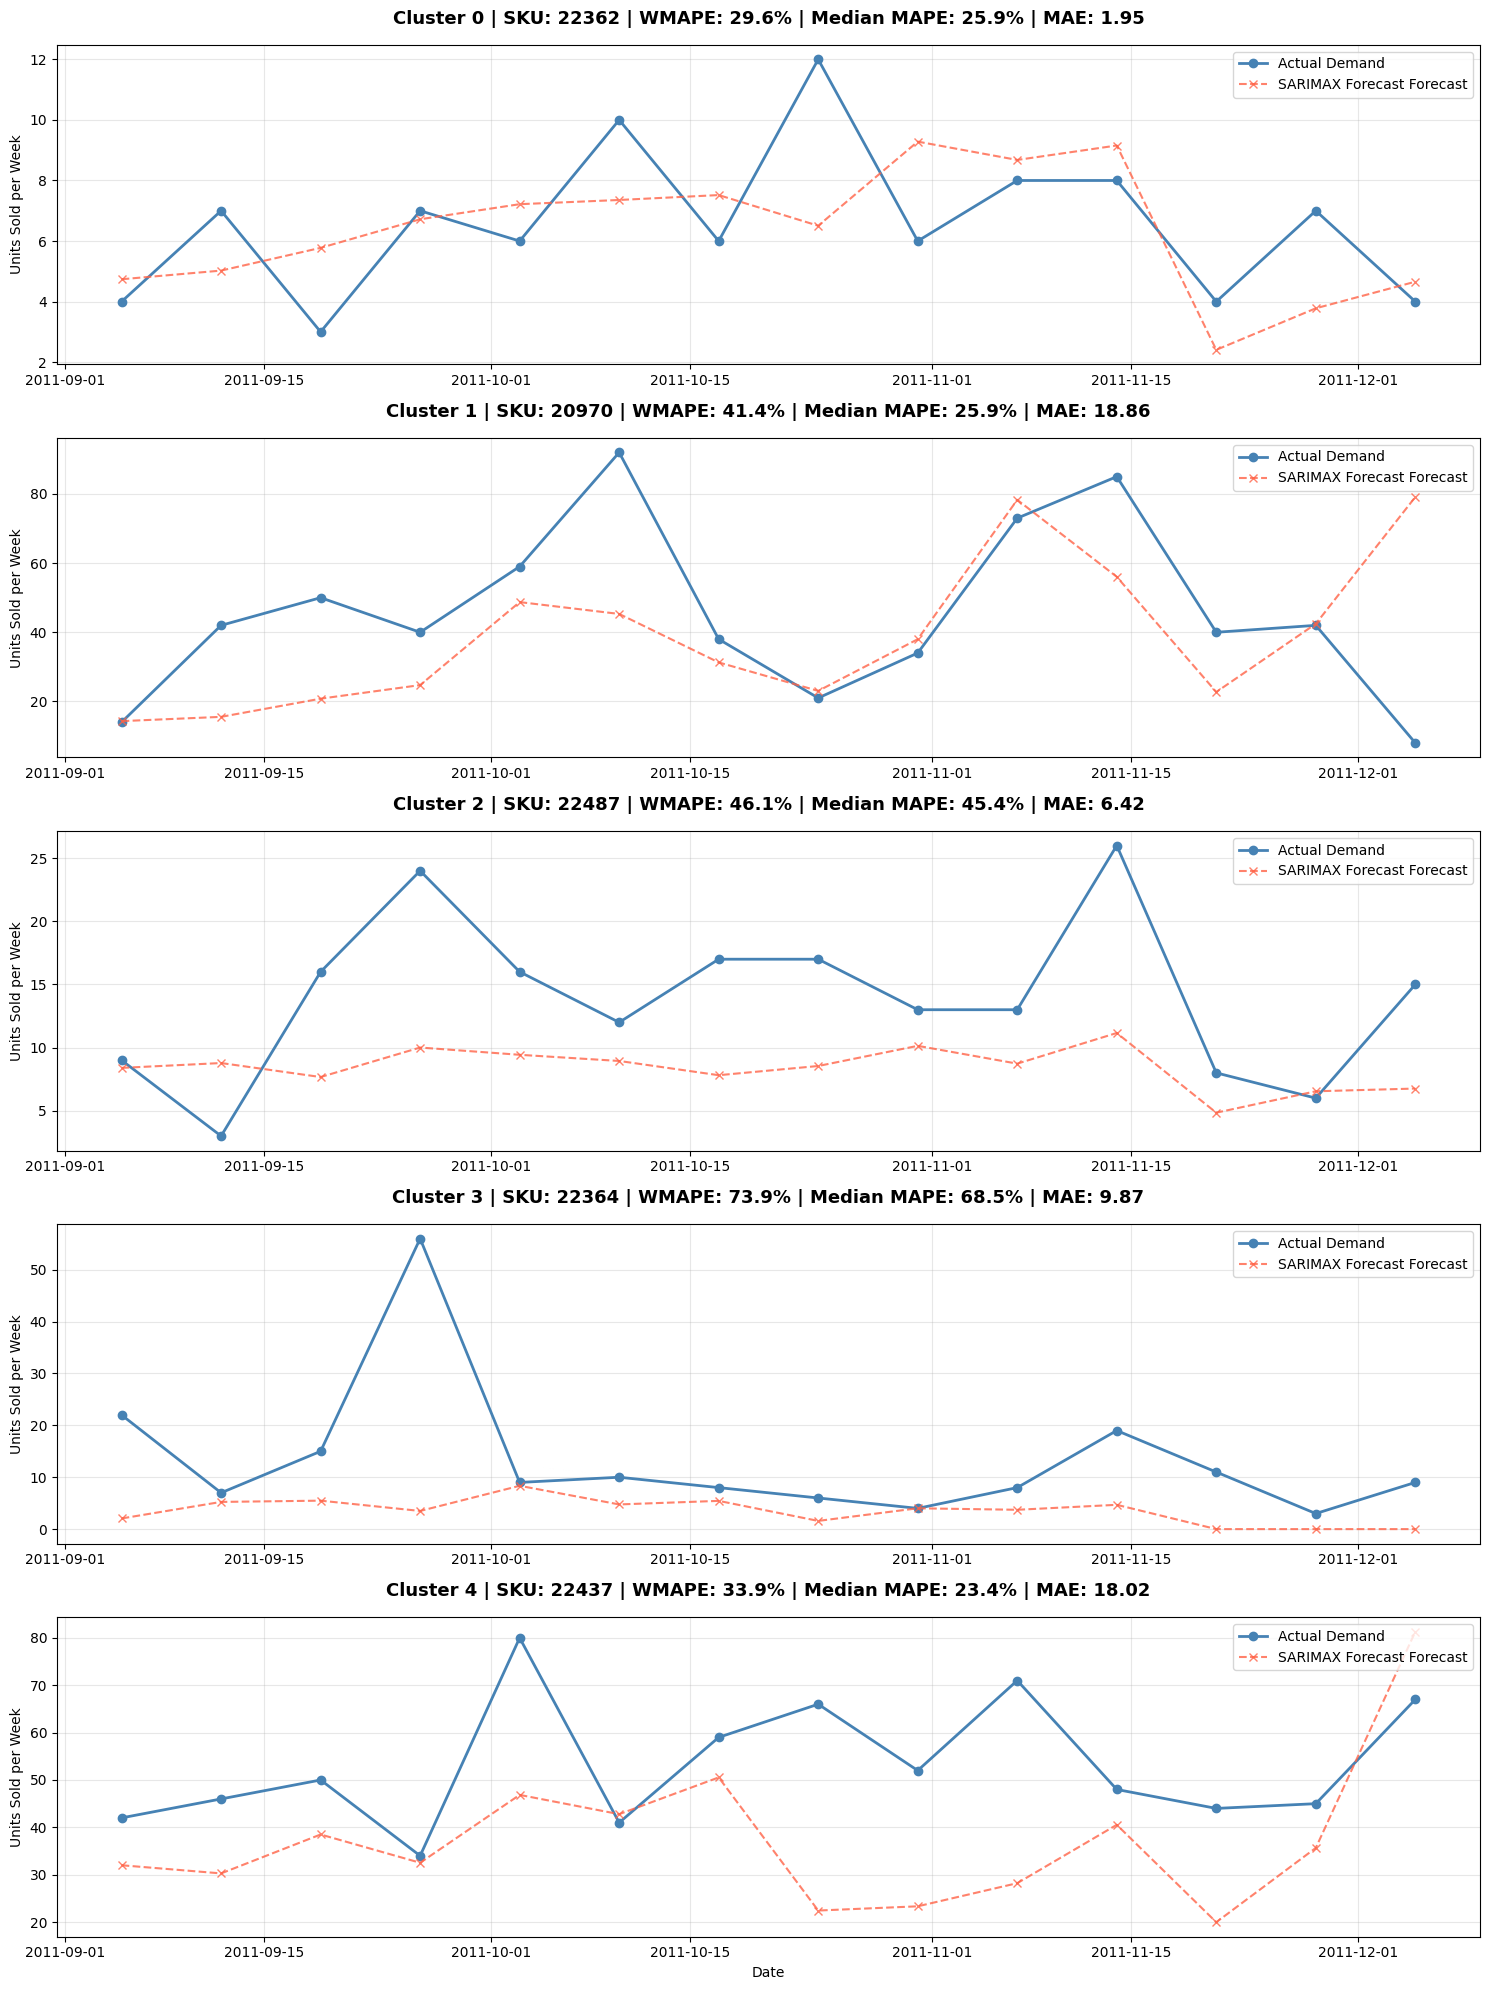

/Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/src/tools/visualization.py:188: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sku_metrics = cluster_eval.groupby("StockCode", observed=True).apply(calc_sku_metrics).dropna()


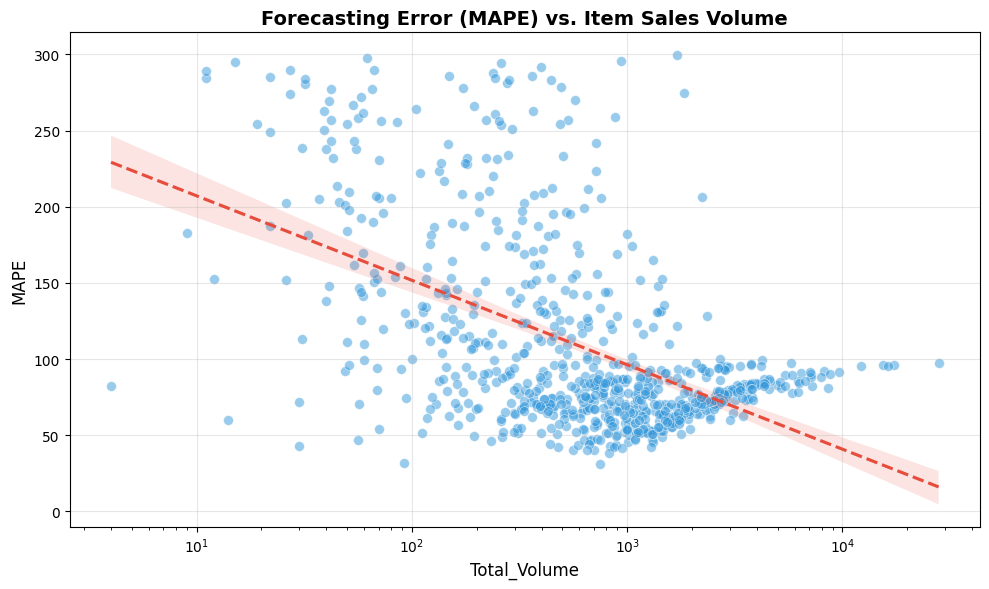

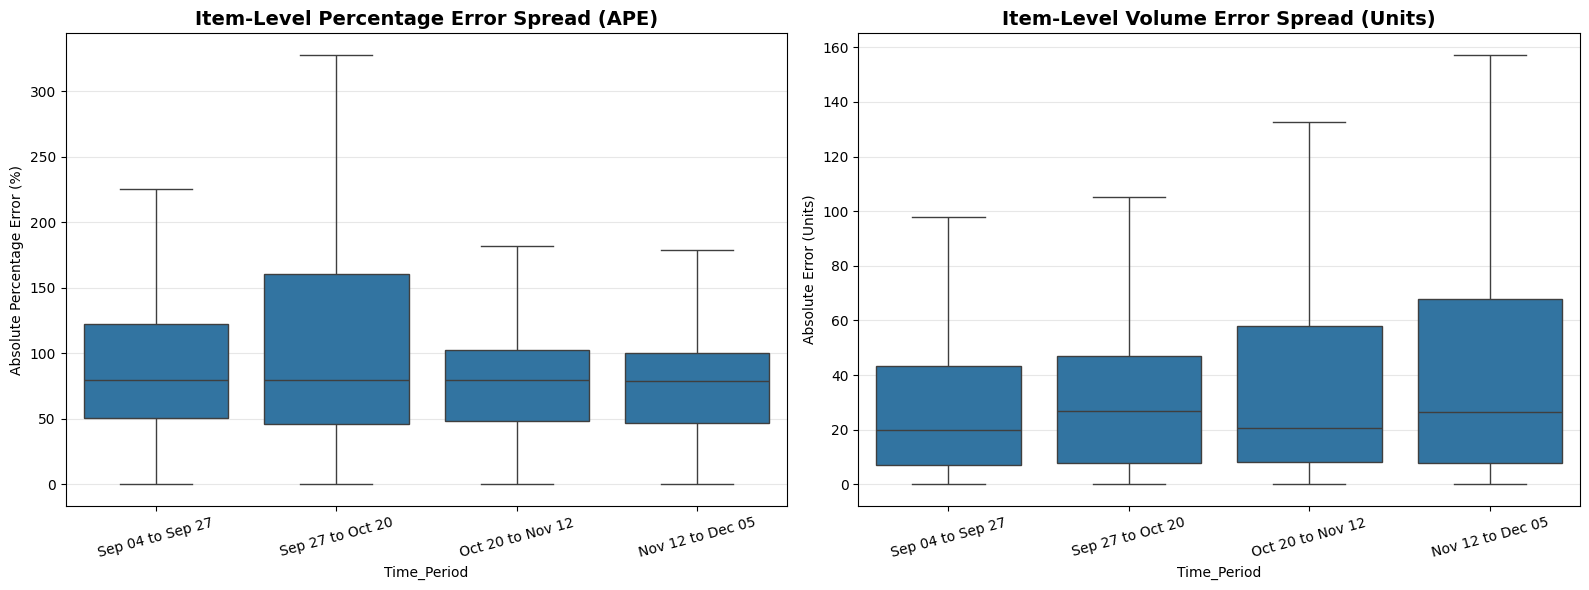

,WMAPE,Median_MAPE,Mean_Absolute_Error
Time_Period,,,
Sep 04 to Sep 27,89.99,79.81,58.84
Sep 27 to Oct 20,89.55,79.92,62.69
Oct 20 to Nov 12,90.43,79.53,68.09
Nov 12 to Dec 05,90.89,78.94,72.27


In [7]:
plot_cluster_portfolio(cluster_eval, summary, model_label="SARIMAX Forecast")
plot_mape_vs_volume(cluster_eval)

# Analyze the drift of error over time
analyze_time_periods(test_raw)

# 7 Save Artifacts

In [8]:
sku_clusters = df_long.drop_duplicates(subset=['StockCode']).set_index('StockCode')['profile_cluster_id'].to_dict()
save_artifacts(cluster_models, regressors, sku_clusters, best_params=best_params, artifacts_dir=os.path.join(PROJECT_ROOT, 'agent', 'artifacts'))

Saving Cluster SARIMAX artifacts to /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/agent/artifacts...
Successfully saved /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/agent/artifacts/sarimax_cluster_models.pkl
Saved best params to /Users/federicogiorgi/Library/CloudStorage/OneDrive-Personal/Documenti/GitHub/forecasting-retail/agent/artifacts/sarimax_best_params.json
